## Nama: Neilson Christopher
## NIM: 2802461965
## Link video penjelasan: https://drive.google.com/drive/folders/1cQ9_NjJqGKd4r6E4iz81gfCT_WtzwLU6?usp=sharing

In [1]:
# import tensorflow as tf

# gpus = tf.config.list_physical_devices('GPU')
# if gpus:
#     try:
#         tf.config.experimental.set_memory_growth(gpus[0], True)
#         print("GPU aktif:", gpus)
#     except RuntimeError as e:
#         print(e)

GPU aktif: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
import os

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
data_dir = "/content/drive/MyDrive/data"

In [5]:
tf.test.gpu_device_name()

'/device:GPU:0'

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras import layers, models

##EDA

Class distribution: {'Cherry_shot hole disease': 440, 'Cherry Leaf Scorch': 870, 'Cherry purple leaf spot': 960, 'Cherry Normal leaf': 500, 'Cherry brown_spot': 510}
Average width: 800.0
Average height: 1000.0


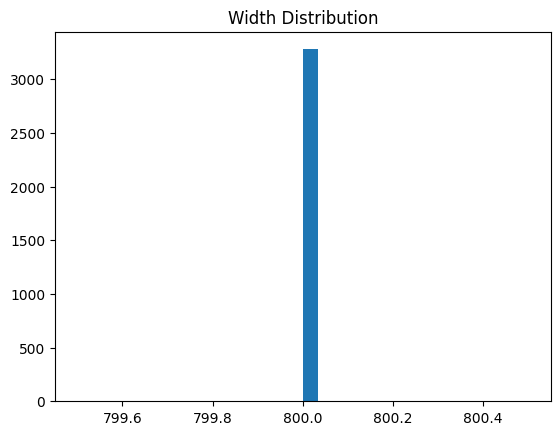

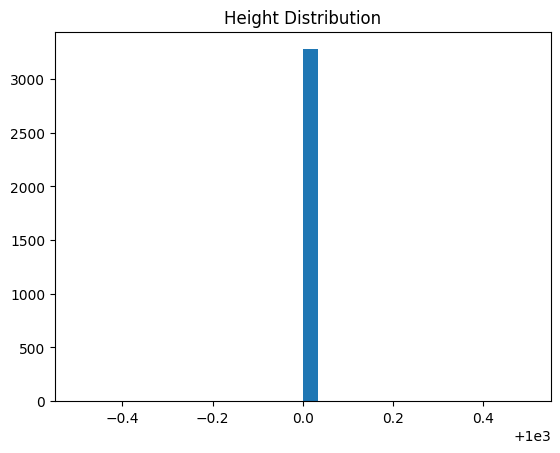

In [7]:
image_sizes = []
labels = []
class_counts = {}

for class_name in os.listdir(data_dir):
    class_path = os.path.join(data_dir, class_name)

    if not os.path.isdir(class_path):
        continue

    count = 0

    for img_name in os.listdir(class_path):
        img_path = os.path.join(class_path, img_name)

        if not os.path.isfile(img_path):
            continue

        if not img_name.lower().endswith(('.jpg', '.jpeg', '.png')):
            continue

        try:
            img = Image.open(img_path)
            image_sizes.append(img.size)
            labels.append(class_name)
            count += 1
        except:
            continue

    class_counts[class_name] = count

# jumlah per class
print("Class distribution:", class_counts)

# cek resolusi
widths = [s[0] for s in image_sizes]
heights = [s[1] for s in image_sizes]

print("Average width:", np.mean(widths))
print("Average height:", np.mean(heights))

# plot distribusi
plt.hist(widths, bins=30)
plt.title("Width Distribution")
plt.show()

plt.hist(heights, bins=30)
plt.title("Height Distribution")
plt.show()

##Load The Data

In [8]:
all_images = []
all_labels = []

class_names = sorted(os.listdir(data_dir))

for label in class_names:
    path = os.path.join(data_dir, label)
    for file in os.listdir(path):
        all_images.append(os.path.join(path, file))
        all_labels.append(label)

# split train 70%
x_train, x_temp, y_train, y_temp = train_test_split(
    all_images, all_labels, test_size=0.3, stratify=all_labels, random_state=42
)

# split val & test (15% each)
x_val, x_test, y_val, y_test = train_test_split(
    x_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42
)

print(len(x_train), len(x_val), len(x_test))

2296 492 492


In [9]:
#set image size to 224,224
IMG_SIZE = 224

def preprocess(img_path, label):
    img = tf.io.read_file(img_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
    img = tf.cast(img, tf.float32) / 255.0 #normalise gambar menjadi tipe pixel
    return img, label



In [10]:
class_names = sorted(list(set(all_labels)))
label_to_index = {label:i for i,label in enumerate(class_names)}

y_train = [label_to_index[l] for l in y_train]
y_val   = [label_to_index[l] for l in y_val]
y_test  = [label_to_index[l] for l in y_test]

In [11]:
train_ds = tf.data.Dataset.from_tensor_slices((x_train, y_train))
val_ds   = tf.data.Dataset.from_tensor_slices((x_val, y_val))
test_ds  = tf.data.Dataset.from_tensor_slices((x_test, y_test))

In [12]:
AUTOTUNE = tf.data.AUTOTUNE

In [13]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

In [14]:
def preprocess_train(path, label):
    img, label = preprocess(path, label)
    img = data_augmentation(img)
    return img, label

In [15]:
train_ds = train_ds.shuffle(1000)
train_ds = train_ds.map(preprocess_train, num_parallel_calls=tf.data.AUTOTUNE)
train_ds = train_ds.batch(16).prefetch(AUTOTUNE)

In [16]:
val_ds = val_ds.map(preprocess_train, num_parallel_calls=AUTOTUNE)
val_ds = val_ds.batch(16).prefetch(AUTOTUNE)

test_ds = test_ds.map(preprocess_train, num_parallel_calls=AUTOTUNE)
test_ds = test_ds.batch(16).prefetch(AUTOTUNE)

In [17]:
num_classes = len(class_names)

def build_alexnet():
    model = models.Sequential()

    model.add(layers.Conv2D(96, (11,11), strides=4, activation='relu', input_shape=(224,224,3)))
    model.add(layers.MaxPooling2D((3,3), strides=2))

    #padding same -> menambahkan zero padding di pinggir gambar
    model.add(layers.Conv2D(256, (5,5), padding='same', activation='relu'))
    model.add(layers.MaxPooling2D((3,3), strides=2))

    model.add(layers.Conv2D(384, (3,3), padding='same', activation='relu'))
    model.add(layers.Conv2D(384, (3,3), padding='same', activation='relu'))

    model.add(layers.Conv2D(256, (3,3), padding='same', activation='relu'))
    model.add(layers.MaxPooling2D((3,3), strides=2))

    model.add(layers.Flatten())

    model.add(layers.Dense(4096, activation='relu'))
    model.add(layers.Dropout(0.5))

    model.add(layers.Dense(4096, activation='relu'))
    model.add(layers.Dropout(0.5))

    model.add(layers.Dense(num_classes, activation='softmax'))

    return model

model = build_alexnet()

model.compile(
    optimizer= tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 54, 54, 96)     │        34,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 26, 26, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 26, 26, 256)    │       614,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 384)    │       885,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 12, 12, 384)    │     1,327,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 12, 12, 256)    │       884,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 5, 5, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6400)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4096)           │    26,218,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 5)              │        20,485 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 46,767,493 (178.40 MB)

 Trainable params: 46,767,493 (178.40 MB)

 Non-trainable params: 0 (0.00 B)

In [19]:
print(type(y_train[0]))

<class 'int'>


In [20]:
for img, label in train_ds.take(1):
    print(img.dtype)     # harus float32
    print(label.dtype)   #

<dtype: 'float32'>
<dtype: 'int32'>


In [21]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weights = compute_class_weight(
    'balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights = dict(enumerate(class_weights))

In [22]:
history = model.fit(
    train_ds,
    validation_data= val_ds,
    epochs=20,
    class_weight=class_weights,
    batch_size=16
)

Epoch 1/10
144/144 ━━━━━━━━━━━━━━━━━━━━ 67s 390ms/step - accuracy: 0.3014 - loss: 1.5476 - val_accuracy: 0.3150 - val_loss: 1.5174
Epoch 2/10
144/144 ━━━━━━━━━━━━━━━━━━━━ 48s 337ms/step - accuracy: 0.6089 - loss: 1.1250 - val_accuracy: 0.7236 - val_loss: 0.7412
Epoch 3/10
144/144 ━━━━━━━━━━━━━━━━━━━━ 83s 348ms/step - accuracy: 0.7134 - loss: 0.8205 - val_accuracy: 0.7825 - val_loss: 0.5818
Epoch 4/10
144/144 ━━━━━━━━━━━━━━━━━━━━ 81s 344ms/step - accuracy: 0.7709 - loss: 0.6572 - val_accuracy: 0.8354 - val_loss: 0.4994
Epoch 5/10
144/144 ━━━━━━━━━━━━━━━━━━━━ 46s 319ms/step - accuracy: 0.8132 - loss: 0.5420 - val_accuracy: 0.8252 - val_loss: 0.4382
Epoch 6/10
144/144 ━━━━━━━━━━━━━━━━━━━━ 46s 322ms/step - accuracy: 0.8406 - loss: 0.4857 - val_accuracy: 0.7805 - val_loss: 0.5504
Epoch 7/10
144/144 ━━━━━━━━━━━━━━━━━━━━ 50s 349ms/step - accuracy: 0.8506 - loss: 0.4358 - val_accuracy: 0.8862 - val_loss: 0.2968
Epoch 8/10
144/144 ━━━━━━━━━━━━━━━━━━━━ 79s 328ms/step - accuracy: 0.8632 - loss: 0

In [23]:
y_pred = model.predict(test_ds)
y_pred = np.argmax(y_pred, axis=1)

print(classification_report(y_test, y_pred, target_names=class_names))

31/31 ━━━━━━━━━━━━━━━━━━━━ 10s 290ms/step
                          precision    recall  f1-score   support

      Cherry Leaf Scorch       0.92      0.94      0.93       131
      Cherry Normal leaf       0.72      0.80      0.76        75
       Cherry brown_spot       0.74      0.93      0.83        76
 Cherry purple leaf spot       1.00      0.88      0.94       144
Cherry_shot hole disease       0.92      0.74      0.82        66

                accuracy                           0.87       492
               macro avg       0.86      0.86      0.86       492
            weighted avg       0.89      0.87      0.88       492



In [31]:
def modif_alexnet():
    model2 = models.Sequential()

    model2.add(layers.Conv2D(96, (11,11), strides=4, activation='relu'))
    model2.add(layers.BatchNormalization())
    model2.add(layers.MaxPooling2D((3,3), strides=2))

    model2.add(layers.Conv2D(256, (5,5), padding='same', activation='relu'))
    model2.add(layers.BatchNormalization())
    model2.add(layers.MaxPooling2D((3,3), strides=2))

    model2.add(layers.Conv2D(384, (3,3), padding='same', activation='relu'))
    model2.add(layers.BatchNormalization())

    model2.add(layers.Conv2D(384, (3,3), padding='same', activation='relu'))
    model2.add(layers.BatchNormalization())

    model2.add(layers.Conv2D(256, (3,3), padding='same', activation='relu'))
    model2.add(layers.BatchNormalization())
    model2.add(layers.MaxPooling2D((3,3), strides=2))

    model2.add(layers.Flatten())

    model2.add(layers.Dense(num_classes, activation='softmax'))

    return model2

model2 = modif_alexnet()

model2.compile(
    optimizer= tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model2.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_10 (Conv2D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [32]:
history2 = model2.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    class_weight=class_weights,
    batch_size=16
)

Epoch 1/20
144/144 ━━━━━━━━━━━━━━━━━━━━ 58s 342ms/step - accuracy: 0.5736 - loss: 1.4176 - val_accuracy: 0.2967 - val_loss: 1.5497
Epoch 2/20
144/144 ━━━━━━━━━━━━━━━━━━━━ 76s 331ms/step - accuracy: 0.7435 - loss: 0.7687 - val_accuracy: 0.3455 - val_loss: 1.5685
Epoch 3/20
144/144 ━━━━━━━━━━━━━━━━━━━━ 49s 342ms/step - accuracy: 0.8314 - loss: 0.5437 - val_accuracy: 0.5589 - val_loss: 1.2166
Epoch 4/20
144/144 ━━━━━━━━━━━━━━━━━━━━ 45s 311ms/step - accuracy: 0.8467 - loss: 0.4809 - val_accuracy: 0.7663 - val_loss: 0.6060
Epoch 5/20
144/144 ━━━━━━━━━━━━━━━━━━━━ 45s 310ms/step - accuracy: 0.8667 - loss: 0.3989 - val_accuracy: 0.8720 - val_loss: 0.3331
Epoch 6/20
144/144 ━━━━━━━━━━━━━━━━━━━━ 46s 319ms/step - accuracy: 0.8976 - loss: 0.3281 - val_accuracy: 0.8943 - val_loss: 0.2815
Epoch 7/20
144/144 ━━━━━━━━━━━━━━━━━━━━ 47s 329ms/step - accuracy: 0.9068 - loss: 0.2983 - val_accuracy: 0.8313 - val_loss: 0.4541
Epoch 8/20
144/144 ━━━━━━━━━━━━━━━━━━━━ 44s 308ms/step - accuracy: 0.9138 - loss: 0

In [33]:
y_pred2 = model2.predict(test_ds)
y_pred2 = tf.argmax(y_pred2, axis=1)

print(classification_report(y_test, y_pred2, target_names=class_names))

31/31 ━━━━━━━━━━━━━━━━━━━━ 8s 222ms/step
                          precision    recall  f1-score   support

      Cherry Leaf Scorch       1.00      0.97      0.98       131
      Cherry Normal leaf       0.82      0.89      0.85        75
       Cherry brown_spot       0.95      0.92      0.93        76
 Cherry purple leaf spot       0.98      0.99      0.99       144
Cherry_shot hole disease       0.92      0.88      0.90        66

                accuracy                           0.95       492
               macro avg       0.93      0.93      0.93       492
            weighted avg       0.95      0.95      0.95       492



In [34]:
from collections import Counter
print("Train distribution:", Counter(y_train))
print("Val distribution:", Counter(y_val))
print("Test distribution:", Counter(y_test))

Train distribution: Counter({3: 672, 0: 609, 2: 357, 1: 350, 4: 308})
Val distribution: Counter({3: 144, 0: 130, 2: 77, 1: 75, 4: 66})
Test distribution: Counter({3: 144, 0: 131, 2: 76, 1: 75, 4: 66})


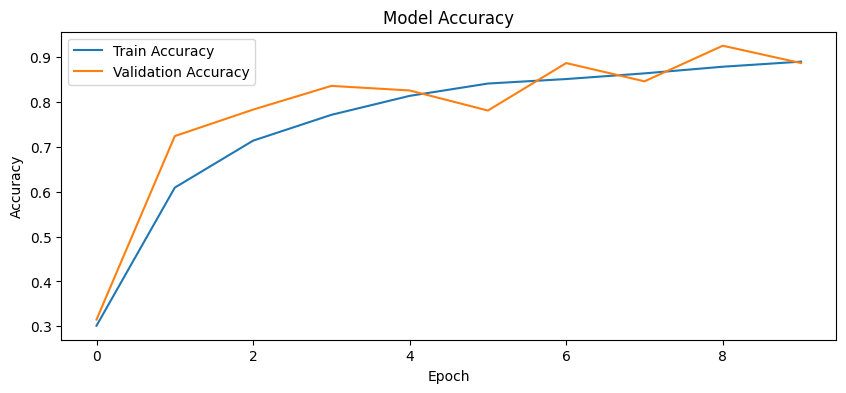

In [35]:
import matplotlib.pyplot as plt

# Accuracy
plt.figure(figsize=(10,4))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


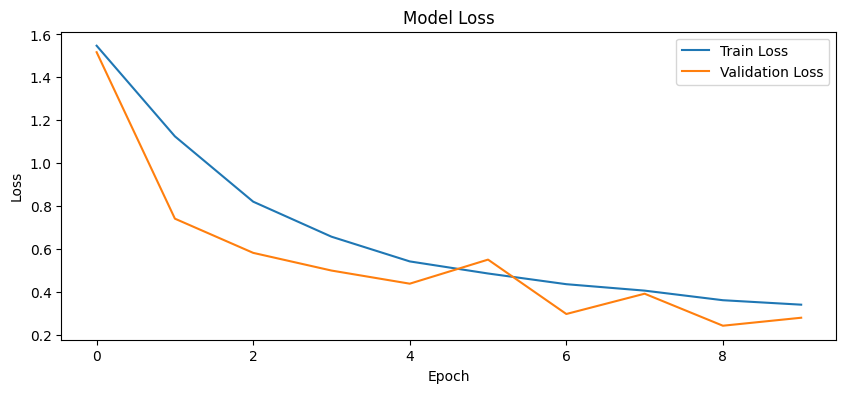

In [36]:

# Loss
plt.figure(figsize=(10,4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

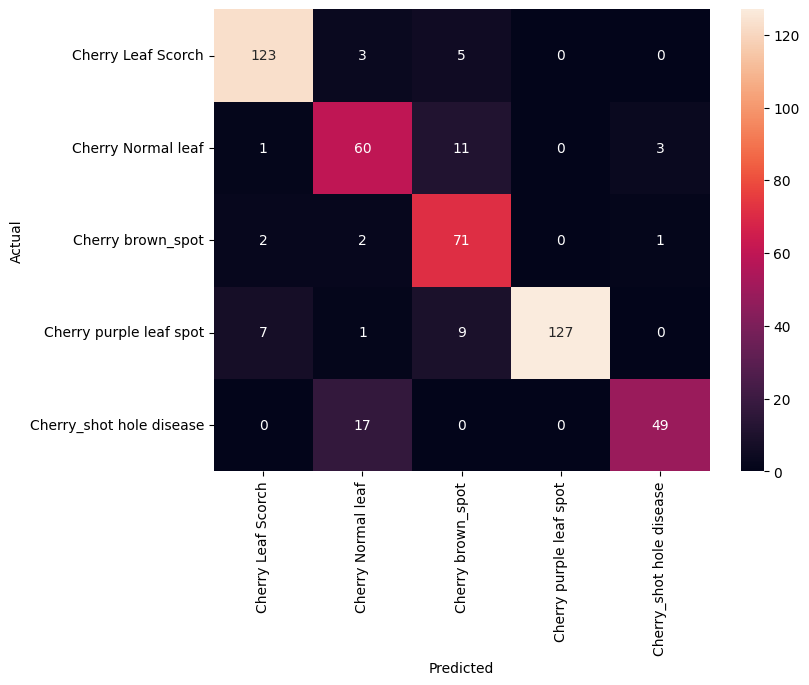

In [37]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()